# Exploratory Data Analysis for Titanic Data Set

Step 1: Importing Libraries

NOTE:
This Data Set was gotten from kaggle.com

In [1]:
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation and analysis
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive, and animated visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization based on Matplotlib

# Set default aesthetic parameters for plots
sns.set_style("whitegrid")
plt.style.use("ggplot")

# Import scikit-learn modules for data cleaning and preprocessing
from sklearn.impute import SimpleImputer  # Used for handling missing values
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Used for scaling numerical features and encoding categorical features
from sklearn.compose import ColumnTransformer # Used for applying different transformations to different columns
from sklearn.pipeline import Pipeline # Used for creating a sequence of data processing steps

Step 2: Loading The Data Set

In [2]:
from google.colab import files # Import the files module from google.colab to handle file uploads

# Upload the file from your local computer
uploaded = files.upload()

# Get the name of the uploaded file
file_name = next(iter(uploaded)) # Assumes only one file is uploaded

# Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the first 5 rows of the DataFrame to verify the load
display(df.head())

Saving Titanic dataset.csv to Titanic dataset.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.tail() #To display the last five rows in te dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [4]:
df.shape #To display the number of rows and columns in the data set

(418, 12)

Step 3: Understanding The Dataset

In [5]:
df.columns #To display all the columns in the dataset

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Data Dictionary:**

PassengerId: A unique identification number for each passenger.

Survived: Indicates whether the passenger survived (1) or not (0).

Pclass: The passenger's class (1st, 2nd, or 3rd class), which can indicate socio-economic status.

Name: The name of the passenger.

Sex: The gender of the passenger (male or female).

Age: The age of the passenger.

SibSp: The number of siblings/spouses aboard the Titanic.

Parch: The number of parents/children aboard the Titanic.

Ticket: The ticket number.

Fare: The fare paid by the passenger.

Cabin: The cabin number.

Embarked: The port where the passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton)

In [6]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [7]:
df.info() #To show columns and number of non blanks entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
df.isnull().sum() #To show the total number of blank cells in the dataset

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [9]:
df.describe() #To display statistical summary of your dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Step 4: Data Cleaning

In [10]:
#To handle missing values, replace missing ages with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

#Replace missing fares with the median
df['Fare'].fillna(df['Fare'].median(), inplace=True)

#Replace missing cabin with unknown
df['Cabin'].fillna('Unknown', inplace=True)


/tmp/ipykernel_1195/248548630.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1195/248548630.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df.duplicated().sum() #To check for duplicate rows

df.drop_duplicates() #To remove duplicate rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,Unknown,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,Unknown,S


In [13]:
df['Age'] = df['Age'].astype(int) #Converting age column from float to integer
df['Sex'] = df['Sex'].astype('category') #Convert Sex and Embarked columns to category data type
df['Embarked'] = df['Embarked'].astype('category')
df['Cabin'] = df['Cabin'].astype('category') #Convert Cabin to category data type

In [14]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,category
Age,int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [15]:
df['Sex'].value_counts() #Check for inconsistency in the different columns

,count
Sex,
male,266
female,152


In [16]:
df['Embarked'].value_counts()


,count
Embarked,
S,270
C,102
Q,46


In [17]:
df['Cabin'].value_counts()

,count
Cabin,
Unknown,327
B57 B59 B63 B66,3
C89,2
B45,2
A34,2
...,...
F E57,1
F2,1
F G63,1


Text(0, 0.5, 'Age')

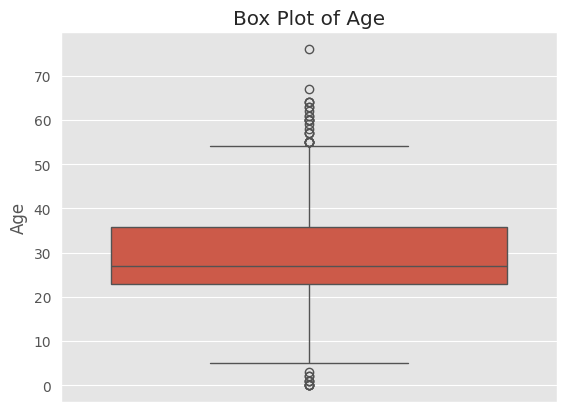

In [18]:
#A boxplot to visualize age and identify outliers
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

Text(0, 0.5, 'Fare')

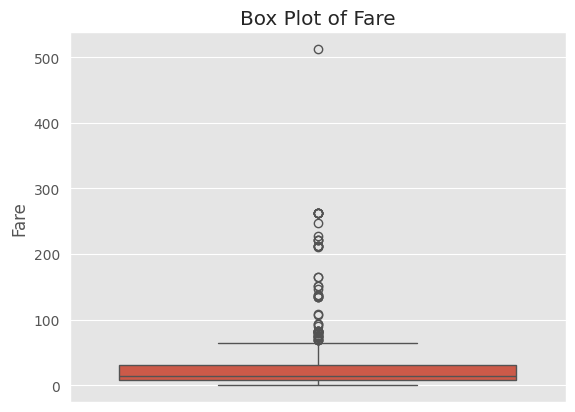

In [19]:
#A boxplot to visualize fare and identify outliers
sns.boxplot(y=df['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Survived     418 non-null    int64   
 2   Pclass       418 non-null    int64   
 3   Name         418 non-null    object  
 4   Sex          418 non-null    category
 5   Age          418 non-null    int64   
 6   SibSp        418 non-null    int64   
 7   Parch        418 non-null    int64   
 8   Ticket       418 non-null    object  
 9   Fare         418 non-null    float64 
 10  Cabin        418 non-null    category
 11  Embarked     418 non-null    category
dtypes: category(3), float64(1), int64(6), object(2)
memory usage: 33.7+ KB


Step 5: Univariate Analysis

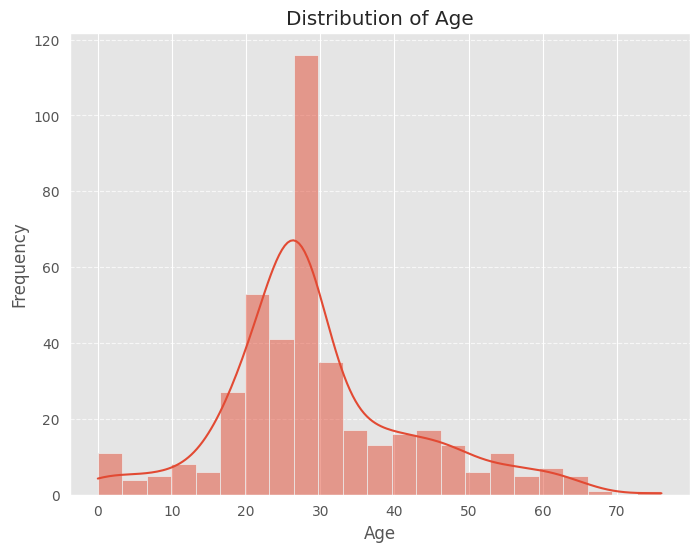

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True)
plt.title(f'Distribution of Age') # Set the chart title
plt.xlabel('Age') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight: The most occuring age range that onboard the titanic ship are young passengers (children)and younger adult age range (around 20-30 years old), and a gradual decrease in frequency for older age groups.

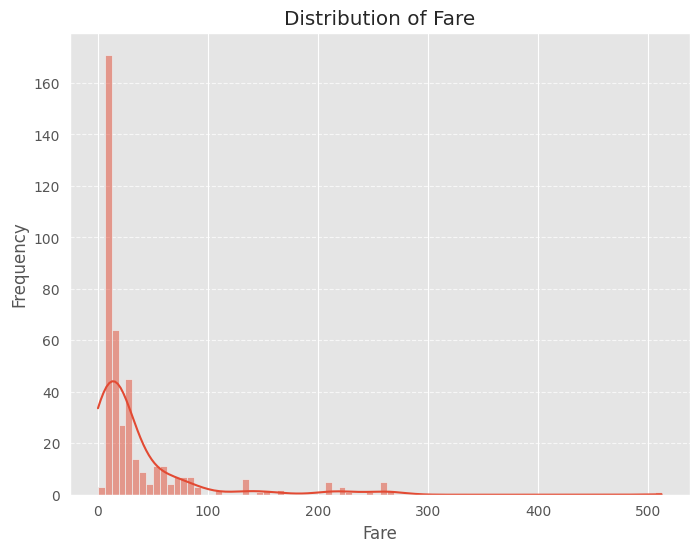

In [22]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Fare'], kde=True)
plt.title(f'Distribution of Fare') # Set the chart title
plt.xlabel('Fare') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight: A large majority of passengers paid lower fares, with a significant concentration in the very low fare range ($5-$100). There are also a very few passengers who paid considerably higher fares of ($200-$250).

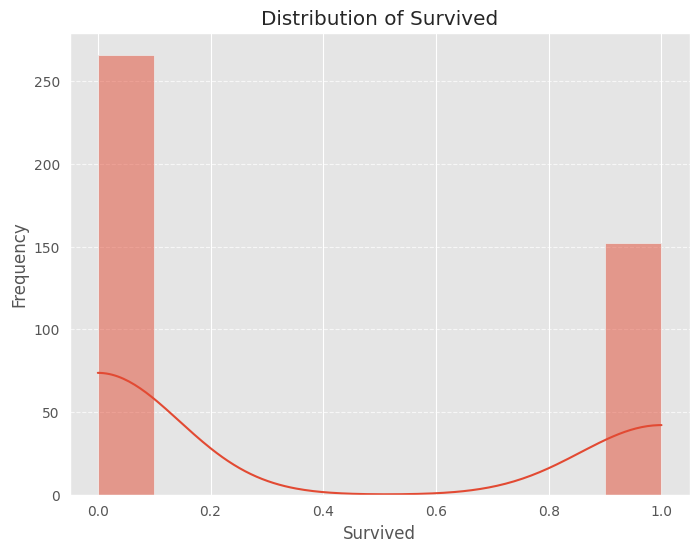

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Survived'], kde=True)
plt.title(f'Distribution of Survived') # Set the chart title
plt.xlabel('Survived') # Set the x-axis label
plt.ylabel('Frequency') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.show() # Display the plot

Insight: The 'Survived' plot clearly shows the count of passengers who did not survive (0) compared to those who did (1). It shows that more passengers did not survive the disaster than those who did. Only 150 passengers survived, and over 250 died.

Step 6: Bivariate Analysis

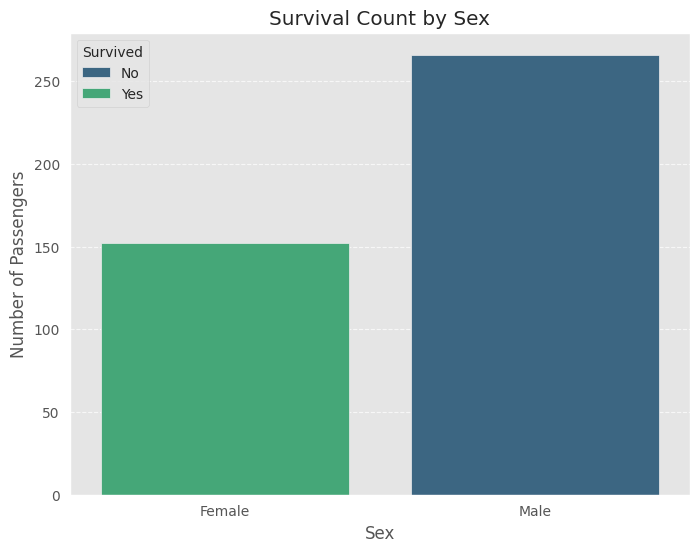

In [24]:
# Create a count plot to visualize the relationship between 'Sex' and 'Survived'
# 'x' is 'Sex', 'hue' is 'Survived' to group bars by survival status, and 'data' is our DataFrame 'df'.
# palette='viridis' sets the color scheme.
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex') # Set the chart title
plt.xlabel('Sex') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Custom x-axis labels for clarity
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: This plot indicates that a significantly higher proportion of female passengers survived compared to male passengers. Conversely, a much larger number of male passengers did not survive, which is over 250 males compared to 150 females who survived. This suggests that gender played a crucial role in survival chances during the Titanic disaster, with females having a considerably better likelihood of survival.

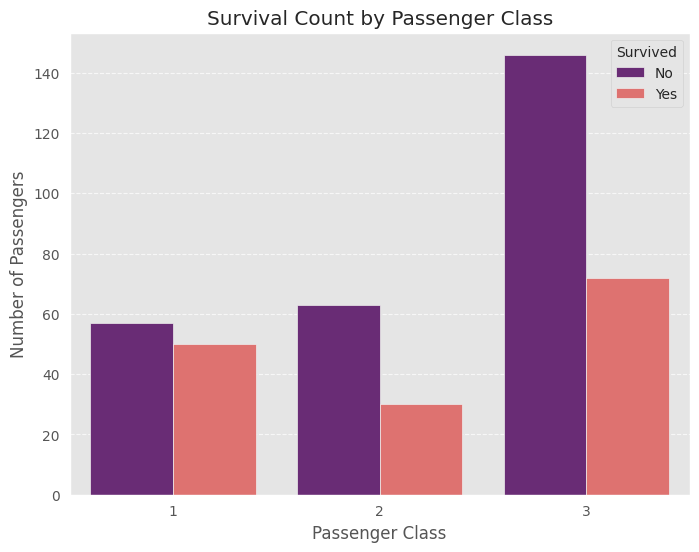

In [25]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Passenger Class') # Set the chart title
plt.xlabel('Passenger Class') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: In summary, while the absolute number of third-class survivors is indeed over 60 passengers, when considering the total number of passengers in each class, it's evident that the survival rate was highest for First Class, followed by Second Class, and significantly lower for Third Class. This re-confirms that passenger class was a strong indicator of survival chances.

/tmp/ipykernel_1195/460570894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='viridis')


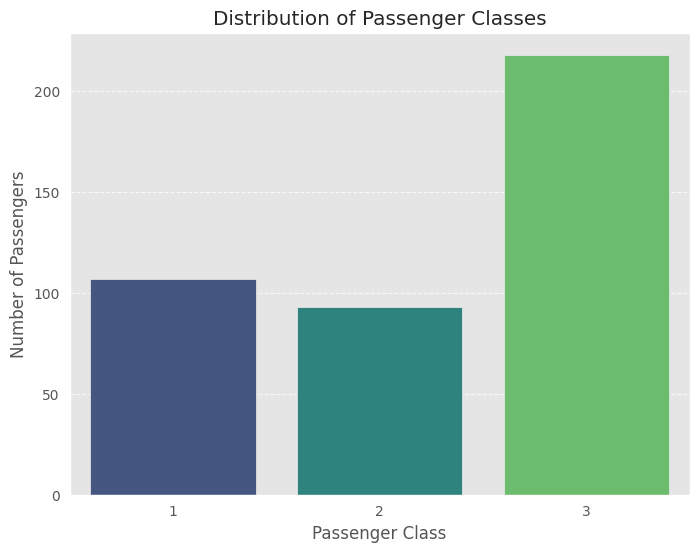

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Distribution of Passenger Classes') # Set the chart title
plt.xlabel('Passenger Class') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot

Insight: This plot shows the absolute number of passengers in each class. It's evident that the 3rd class has the highest number of passengers, followed by the 1st class, and then the 2nd class with the fewest passengers. This indicates that the majority of passengers on the Titanic were traveling in 3rd class.

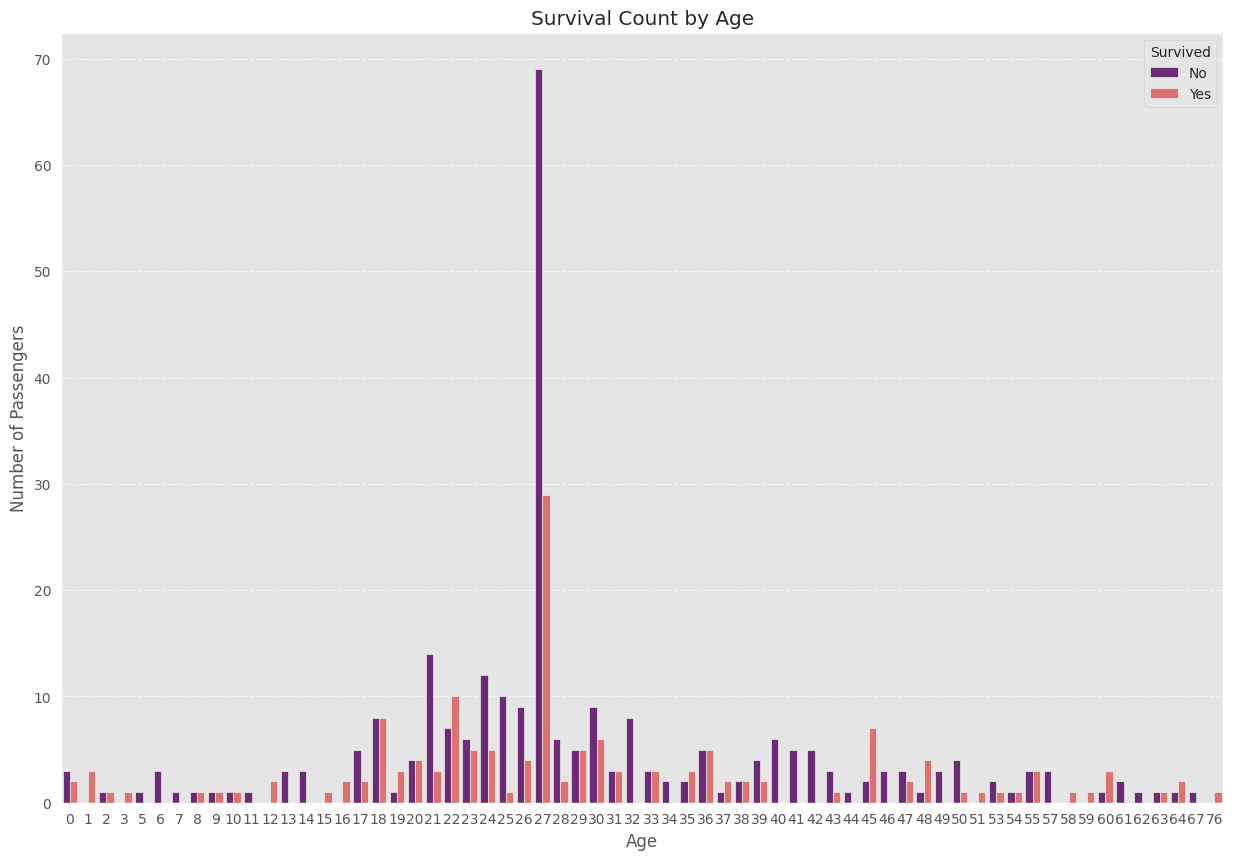

In [27]:
plt.figure(figsize=(15, 10))
sns.countplot(x='Age', hue='Survived', data=df, palette='magma')
plt.title('Survival Count by Age') # Set the chart title
plt.xlabel('Age') # Set the x-axis label
plt.ylabel('Number of Passengers') # Set the y-axis label
plt.legend(title='Survived', labels=['No', 'Yes']) # Add a legend for survival status
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show() # Display the plot



### Insight:

The 'Survival Count by Age' plot reveals that across most age groups, a larger number of passengers did not survive compared to those who did. There's a noticeable trend where non-survival dominates, especially in the young adult to middle-aged ranges (approximately 20-40 years old). While the total number of survivors is lower overall, there might be a slight indication of better survival chances for very young children compared to other age segments.

Step 7: Multivariate Analysis

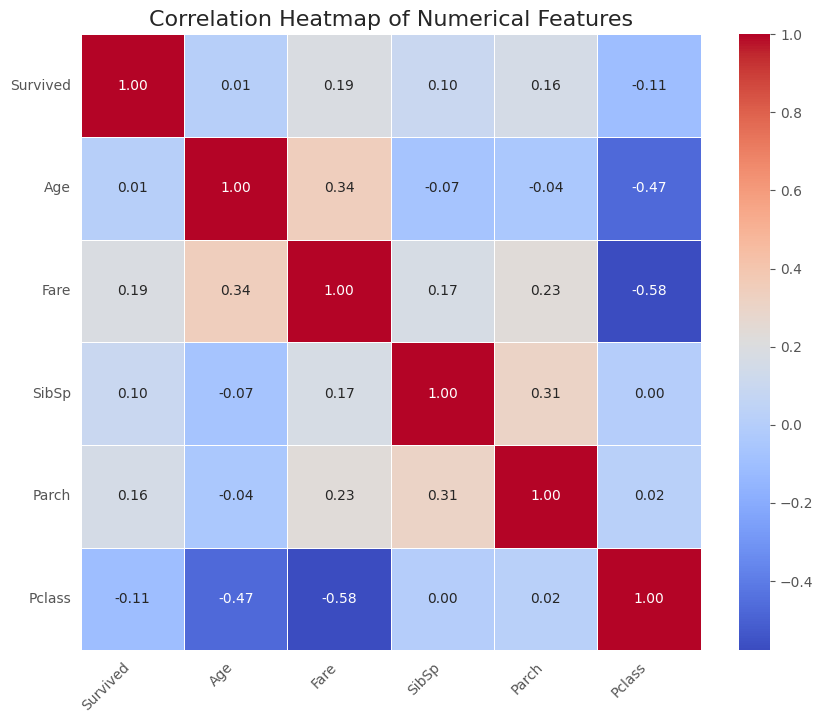

In [28]:
numerical_features = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
# Calculate the pairwise correlation between selected numerical features.
# The .corr() method computes the standard correlation coefficient.
correlation_matrix = df[numerical_features].corr()

# Create a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8)) # Set the size of the plot for optimal readability.
sns.heatmap(correlation_matrix,
            annot=True,     # Display the correlation coefficients on the heatmap cells.
            cmap='coolwarm',  # Use a diverging colormap ('coolwarm' shows positive/negative correlations).
            fmt='.2f',      # Format the annotations to two decimal places.
            linewidths=.5)  # Add lines between cells for better visual separation.
plt.title('Correlation Heatmap of Numerical Features', fontsize=16) # Set a descriptive chart title.
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better legibility.
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal.
plt.show() # Display the generated plot.


## Insight:

Survival (Survived): It has weak positive correlations with Fare and Parch, and a very weak negative correlation with Pclass.

Age and SibSp have almost no linear correlation with survival.

Passenger Class (Pclass): This feature shows strong negative correlations with Fare (-0.58) and Age (-0.47), indicating that higher passenger classes (lower Pclass number) are associated with higher fares and older ages.

Fare: Beyond its correlation with Pclass, Fare has a moderate positive correlation with Age (0.34).

Family Size (SibSp and Parch): These two features are moderately correlated with each other (0.31), as expected, suggesting that passengers traveling with siblings/spouses often also traveled with parents/children. They have weak correlations with other features.


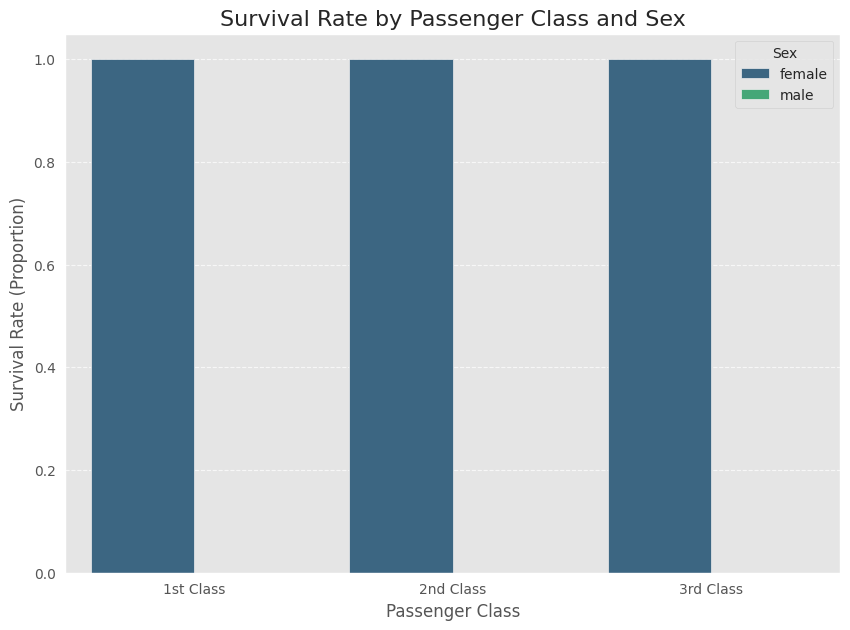

In [29]:
# Calculate the mean survival rate grouped by 'Pclass' and 'Sex'.
# This aggregates the data to show the proportion of survivors (mean of 'Survived')
# for each unique combination of passenger class and gender.
# setting observed=False ensures that all categories, even those not present in a subgroup, are shown.
mean_survival_pclass_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean().reset_index()

# Create a grouped bar plot to visualize the survival rate.
# 'x' represents Pclass on the horizontal axis.
# 'y' represents the calculated mean 'Survived' (survival rate) on the vertical axis.
# 'hue' is set to 'Sex' to create separate bars for 'male' and 'female' within each Pclass group.
plt.figure(figsize=(10, 7)) # Set the size of the plot for better readability.
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=mean_survival_pclass_sex, palette='viridis')
plt.title('Survival Rate by Passenger Class and Sex', fontsize=16) # Set a descriptive chart title.
plt.xlabel('Passenger Class') # Set the x-axis label.
plt.ylabel('Survival Rate (Proportion)') # Set the y-axis label.
# Customize x-axis tick labels for clarity.
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex') # Add a legend to distinguish between male and female bars.
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier comparison of rates.
plt.show() # Display the generated plot.

Insight:

This visual, clearly shows a stark difference in survival probabilities based on both gender and passenger class:

Female Survival Advantage: Across all passenger classes (1st, 2nd, and 3rd), females consistently show a significantly higher survival rate, appearing to be 100% in this specific dataset.

Male Survival Disadvantage: Conversely, males across all passenger classes exhibit a very low or zero survival rate. This suggests that for males, regardless of their passenger class, survival was highly unlikely.

Interaction of Class and Sex: While passenger class often played a role in survival (as seen in earlier analyses), this plot highlights that sex was an even more dominant factor. Even 3rd class females appear to have survived at a higher rate than any male passenger in any class, according to this chart. This strongly reinforces the 'women and children first' protocol's impact on survival, at least for the female population in this dataset.



## Key Insights from Titanic Data Analysis

Based on the exploratory data analysis, the following key insights highlight the factors most strongly associated with survival during the Titanic disaster:

*   **Gender was the primary determinant of survival:** Female passengers consistently exhibited a significantly higher survival rate across all passenger classes. Conversely, male passengers faced a dramatically lower likelihood of survival, regardless of their class, strongly suggesting the influence of the 'women and children first' protocol.

*   **Passenger Class strongly influenced survival probabilities:** First-class passengers had notably superior survival rates compared to those in second and, particularly, third classes. This indicates that socio-economic status, as represented by passenger class, was a significant factor in survival outcomes.

*   **Socio-economic factors (Pclass, Fare, Age) were intertwined:** Higher passenger classes were generally associated with both higher fares and, on average, older passenger demographics, highlighting the socio-economic stratification on board.

*   **Demographic distribution favored younger adults and lower fares:** The majority of passengers were young adults (approximately 20-30 years old), and a significant proportion paid lower fares.

*   **Age and Fare had a weak direct linear relationship with survival:** While `Fare` showed a weak positive correlation with survival, and `Age` had an almost negligible linear correlation, these factors alone did not strongly predict survival in a direct linear manner when compared to gender and class.

*   **Overall, more passengers perished than survived:** The analysis clearly indicates that a majority of individuals on board did not survive the disaster.

## Business Recommendations for New Ship Design and Operations

Based on the insights derived from the Titanic dataset analysis, the following recommendations are provided for a company designing and operating a new passenger vessel, focusing on maximizing safety and ensuring equitable outcomes in emergency situations:

*   **Recommendation: Implement Universal and Sufficient Life-Saving Equipment Capacity.**
    *   **Analytical Evidence:** The analysis revealed that overall, more passengers perished than survived, and a dramatic disparity existed in survival rates between genders, with females having significantly higher survival across all classes. This indicates that the total life-saving capacity or its accessibility was insufficient for all onboard.
    *   **Business Rationale:** Prioritizing and exceeding international maritime safety regulations for life-saving equipment (e.g., lifeboats, rafts) for 100% of passengers and crew is paramount. This ensures basic safety, mitigates catastrophic risk, protects brand reputation, and complies with modern legal and ethical standards.

*   **Recommendation: Establish Equitable Emergency Response and Evacuation Protocols.**
    *   **Analytical Evidence:** The most dominant finding was that gender was the primary determinant of survival, with females consistently experiencing significantly higher survival rates than males across all passenger classes. This implies the enforcement of a 'women and children first' approach, leading to unequal survival chances.
    *   **Business Rationale:** Modern maritime operations must adhere to principles of equality. Emergency protocols should be designed to ensure that all individuals, regardless of gender, class, or other demographics, have an equal and fair opportunity for survival. This aligns with ethical responsibilities and avoids discrimination.

*   **Recommendation: Standardize Safety Measures and Access Across All Passenger Classes.**
    *   **Analytical Evidence:** Passenger class significantly influenced survival probabilities, with First-class passengers exhibiting superior survival rates compared to those in second and, particularly, third classes. This suggests potential disparities in access to safety information, emergency exits, or assistance based on class.
    *   **Business Rationale:** All passenger areas, irrespective of class, must be equipped with clearly marked, easily accessible safety information, life-saving equipment, and clear evacuation routes. Standardizing safety briefings and emergency assistance across all classes enhances overall safety, promotes equity, and fosters passenger trust.

*   **Recommendation: Integrate Diverse Demographic Considerations into Emergency Planning.**
    *   **Analytical Evidence:** The demographic analysis showed a majority of passengers were young adults (20-30 years old), and the correlations between `SibSp` and `Parch` indicated family travel. The age distribution also included children and elderly.
    *   **Business Rationale:** Emergency plans should account for varied passenger demographics, such as families, children, and the elderly. This includes designing child-friendly emergency equipment, designated family assembly points, and tailored assistance for different age groups to optimize evacuation efficiency and minimize panic.

*   **Recommendation: Implement Robust Communication and Real-time Passenger Tracking Systems.**
    *   **Analytical Evidence:** The high overall mortality rate and the significant number of missing `Cabin` data points indirectly suggest challenges in clear passenger identification, location tracking, and broader situational awareness during the historical disaster, which hindered effective rescue efforts.
    *   **Business Rationale:** Investing in state-of-the-art communication and navigation systems is crucial for early warning, distress signaling, and coordinated response. Furthermore, maintaining precise, real-time electronic passenger manifests and cabin assignments can significantly aid in emergency management, accountability, and rescue efforts.

*   **Recommendation: Mandate Comprehensive and Regular Crew Training in Emergency Response.**
    *   **Analytical Evidence:** The stark disparities in survival, particularly by gender and class, imply that human intervention, adherence to protocols, and efficient crew actions played a critical role. Ineffective or unequal application of emergency procedures would exacerbate such disparities.
    *   **Business Rationale:** A well-trained and prepared crew is the cornerstone of effective emergency management. Regular, rigorous training in all aspects of emergency response, including equitable evacuation procedures, crowd control, and crisis communication, ensures that the crew can act decisively and competently, maximizing the chances of survival for all onboard.

## Executive Summary: Titanic Disaster Data Analysis

### Purpose of the Analysis
This executive summary outlines the key insights derived from an exploratory data analysis of the Titanic disaster. The primary objective of this analysis was to meticulously examine various passenger attributes and environmental factors to identify and understand the underlying reasons that influenced survival rates. By dissecting historical data, this study aims to extract critical lessons that can inform and enhance modern maritime safety protocols, emergency preparedness, and passenger welfare strategies for future vessel operations.

### Data Set Description
The analysis utilized a dataset containing information on Titanic passengers, including demographics such as age, sex, passenger class (Pclass), fare, and family-related metrics, alongside their survival status.

### Most Important Findings
The most critical finding reveals that gender was the predominant factor in survival, with female passengers demonstrating significantly higher survival rates across all classes, while males faced substantially lower chances. Passenger class also played a crucial role; first-class passengers had superior survival rates compared to those in lower classes, highlighting the impact of socio-economic status. While age and fare had weaker direct correlations, they were intertwined with passenger class. Overall, the analysis confirms that a majority of individuals onboard perished in the disaster.

### Overall Business Implications
These findings carry significant business implications for modern passenger vessel design and operations. The historical disparities underscore the critical need for universal and sufficient life-saving equipment, ensuring equitable access for all passengers regardless of demographic or social standing. Future emergency response protocols must be designed to guarantee fair and equal opportunities for survival, moving away from past discriminatory practices. Furthermore, standardized safety measures, integration of diverse demographic considerations, and robust communication and tracking systems are paramount to ensure effective emergency management and passenger accountability.

### Conclusion
In conclusion, the analysis of the Titanic disaster provides invaluable lessons, emphasizing the paramount importance of comprehensive safety measures, equitable emergency planning, and robust operational protocols for safeguarding all individuals on board future voyages.